In [1]:
train_dir = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/train"
test_dir  = "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test"

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from PIL import Image
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np

In [3]:
class PneumoDataset(Dataset):
    def __init__(self, root, is_train: bool, img_size=128):
        self.root = root
        self.paths = []
        self.is_train = is_train

        for label_name in os.listdir(root):
            folder = os.path.join(root, label_name)
            for file in os.listdir(folder):
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.paths.append(os.path.join(folder, file))

        # Исправлено: добавлено двоеточие и присвоение self.transform
        if self.is_train:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomAdjustSharpness(sharpness_factor=2),
                T.ToTensor(),
                # Для grayscale изображений нормализация с одним каналом
                T.Normalize([0.5], [0.5])  # для диапазона [-1, 1]
            ])
        else:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.ToTensor(),
                T.Normalize([0.5], [0.5])
            ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("L")  # "L" для grayscale
        img = self.transform(img)

        # метка
        fname = os.path.basename(path).lower()
        if "bacter" in fname:
            label = 1      # бактериальная пневмония
        else:
            label = 0      # вирусная или норм

        return img, label

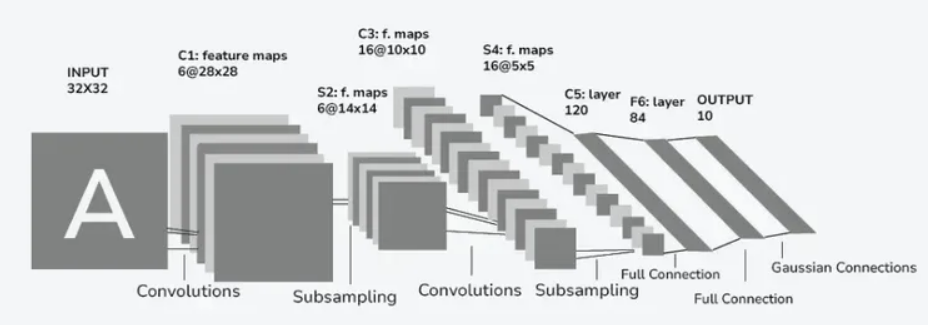

In [4]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # nn.Conv2d(1, 6, kernel_size=5),
            # nn.ReLU(),
            # nn.MaxPool2d(2),

            # nn.Conv2d(6, 16, kernel_size=5),
            # nn.ReLU(),
            # nn.MaxPool2d(2),

            # nn.Flatten(),
            # nn.Linear(16*29*29, 120),  # для 128×128
            # nn.ReLU(),
            # nn.Linear(120, 84),
            # nn.ReLU(),
            # nn.Linear(84, 1)

            nn.Conv2d(1, 6, kernel_size=5),
            nn.BatchNorm2d(6),  # ← добавить
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.BatchNorm2d(16),  # ← добавить
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(16*29*29, 120),
            nn.BatchNorm1d(120),  # ← добавить
            nn.ReLU(),
            nn.Dropout(0.5),  # ← добавить для регуляризации
            
            nn.Linear(120, 84),
            nn.BatchNorm1d(84),  # ← добавить
            nn.ReLU(),
            nn.Dropout(0.3),  # ← добавить
            
            nn.Linear(84, 1)
        )

    def forward(self, x):
        return self.model(x)

In [5]:
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    train_loss = 0
    
    for x, y in tqdm(train_loader, desc='Train'):

        x = x.to(device)
        y = y.to(device).float().unsqueeze(1)  # [batch] -> [batch, 1] для BCEWithLogitsLoss
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    return train_loss / len(train_loader)

In [6]:
@torch.inference_mode()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for x, y in tqdm(loader, desc='Evaluation'):
        x = x.to(device)
        y = y.to(device).float().unsqueeze(1)
        
        output = model(x)
        loss = criterion(output, y)
        total_loss += loss.item()
        
        predicted = (torch.sigmoid(output) > 0.5).float()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    
    total_loss /= len(loader)
    
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    accuracy = (all_preds == all_labels).mean()
    
    return total_loss, accuracy, all_preds, all_labels

In [7]:
def plot_stats(train_loss, valid_loss, valid_accuracy, title):
    plt.figure(figsize=(16, 8))
    plt.title(title + ' loss')
    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(16, 8))
    plt.title(title + ' accuracy')
    plt.plot(valid_accuracy)
    plt.grid()
    plt.show()


In [8]:
train_ds = PneumoDataset(train_dir, is_train=True)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

test_ds = PneumoDataset(test_dir, is_train=False)
valid_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

In [9]:
model = LeNet()
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

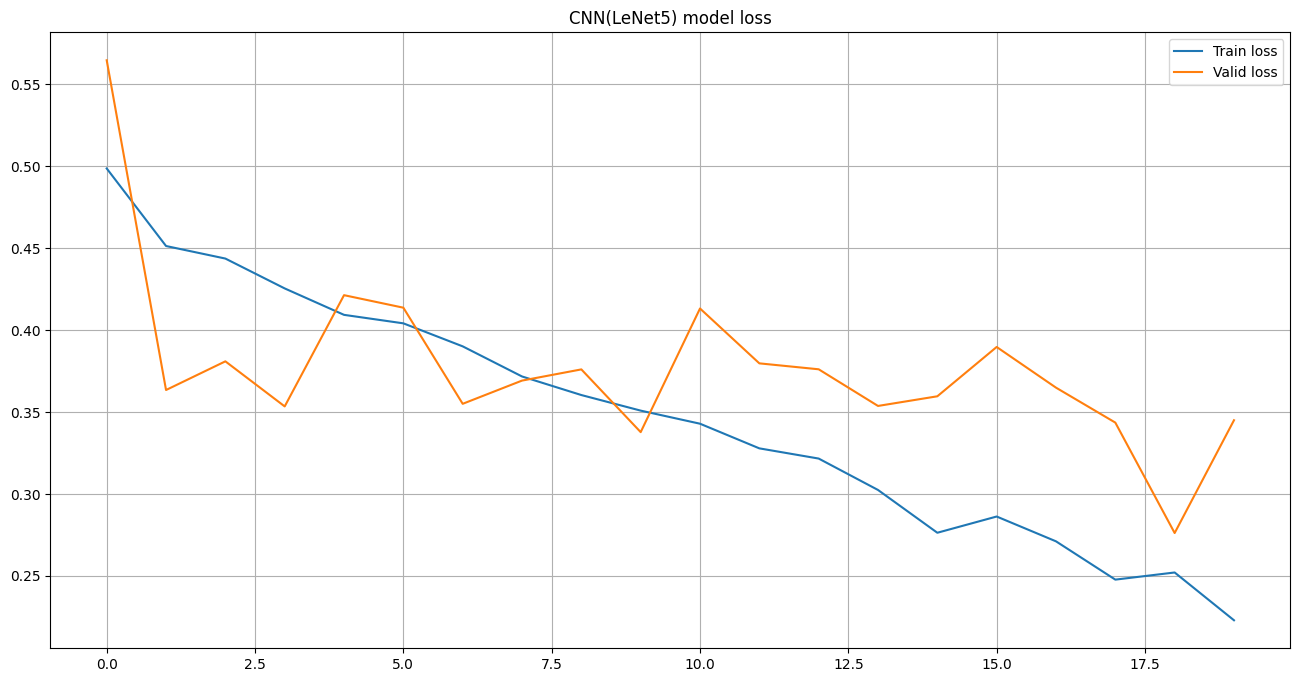

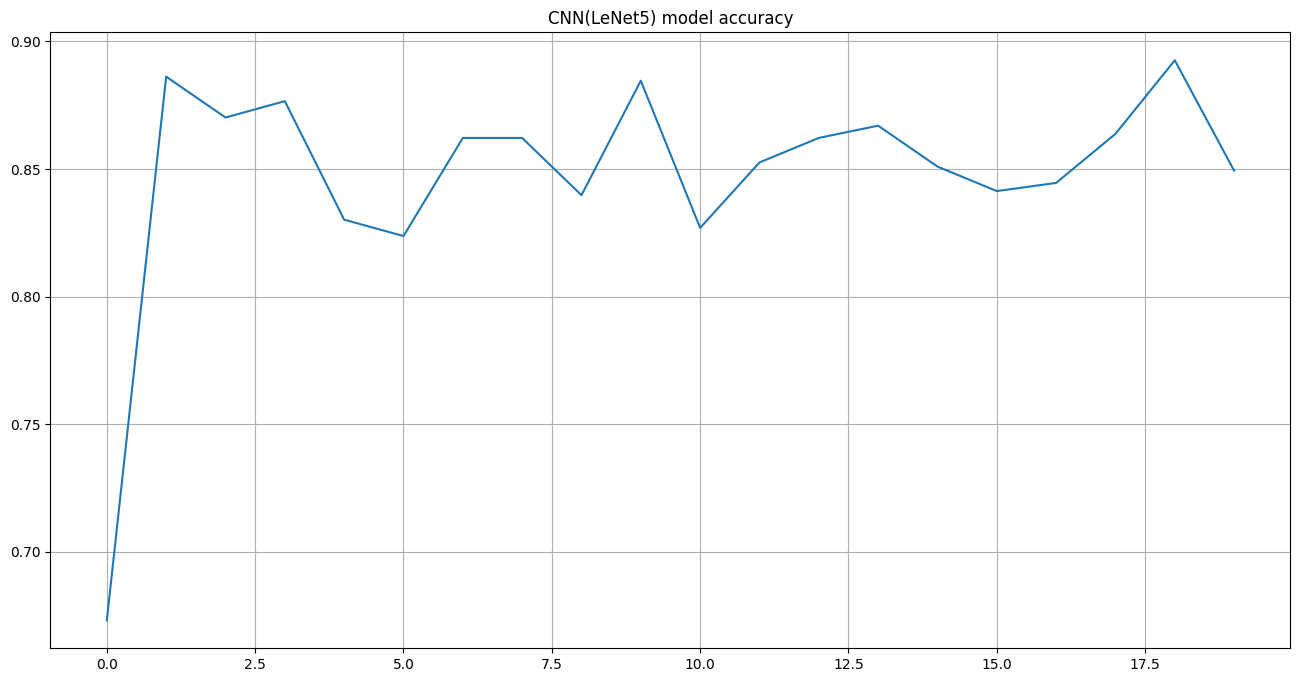

In [10]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_loss_history = []
valid_loss_history = []
valid_accuracy_history = []

best_loss = float('inf') 
best_epoch = 0 

for epoch in range(20):
    print(f"\nEpoch {epoch+1}/20")
    
    train_loss = train(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_accuracy, valid_preds, valid_labels = evaluate(model, valid_loader, criterion, device)
    
    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_accuracy_history.append(valid_accuracy)

    if valid_loss < best_loss:
        best_loss = valid_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pth')

    clear_output()
    plot_stats(train_loss_history, valid_loss_history, valid_accuracy_history, 'CNN(LeNet5) model')


In [11]:
print(f"Лучшая модель была на эпохе {best_epoch} с loss={best_loss:.4f}")

Лучшая модель была на эпохе 18 с loss=0.2762


In [12]:
model.load_state_dict(torch.load('best_model.pth'))

test_loss, test_accuracy, test_preds, test_labels = evaluate(model, valid_loader, criterion, device)
print(f"Test Loss = {test_loss:.4f}, Test Accuracy = {test_accuracy:.4f}")

Evaluation: 100%|██████████| 39/39 [00:04<00:00,  8.10it/s]

Test Loss = 0.2762, Test Accuracy = 0.8926


In [13]:
y_true = np.array(test_labels).flatten()
y_pred = np.array(test_preds).flatten()




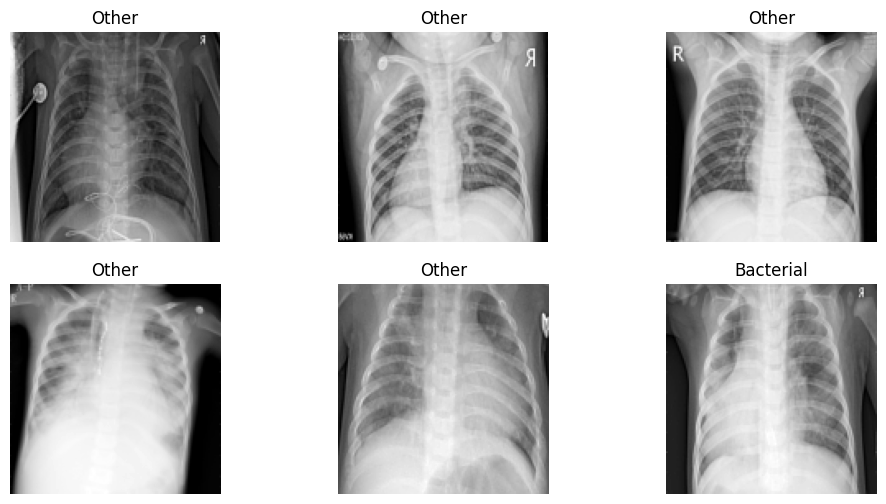

In [14]:

def show_batch(dataset, n=6):
    plt.figure(figsize=(12, 6))

    for i in range(n):
        img, label = dataset[i]
        img = img.squeeze(0)  # убрать канал 1xHxW → HxW

        plt.subplot(2, n//2, i+1)
        plt.imshow(img, cmap="gray")
        plt.title("Bacterial" if label==1 else "Other")
        plt.axis("off")

    plt.show()

show_batch(train_ds)

In [15]:
def visualize_features(model, image_path):
    img = Image.open(image_path).convert("L")
    transform = T.Compose([
        T.Resize((128,128)),
        T.ToTensor()
    ])
    img = transform(img).unsqueeze(0).to(device)

    # пропускаем только первый слой
    with torch.no_grad():
        conv1 = model.model[0](img)  # первый Conv2d

    conv1 = conv1.squeeze(0).cpu()

    plt.figure(figsize=(12, 8))
    for i in range(6):  # 6 карт признаков
        plt.subplot(2, 3, i+1)
        plt.imshow(conv1[i], cmap="gray")
        plt.title(f"Feature map {i+1}")
        plt.axis("off")

    plt.show()


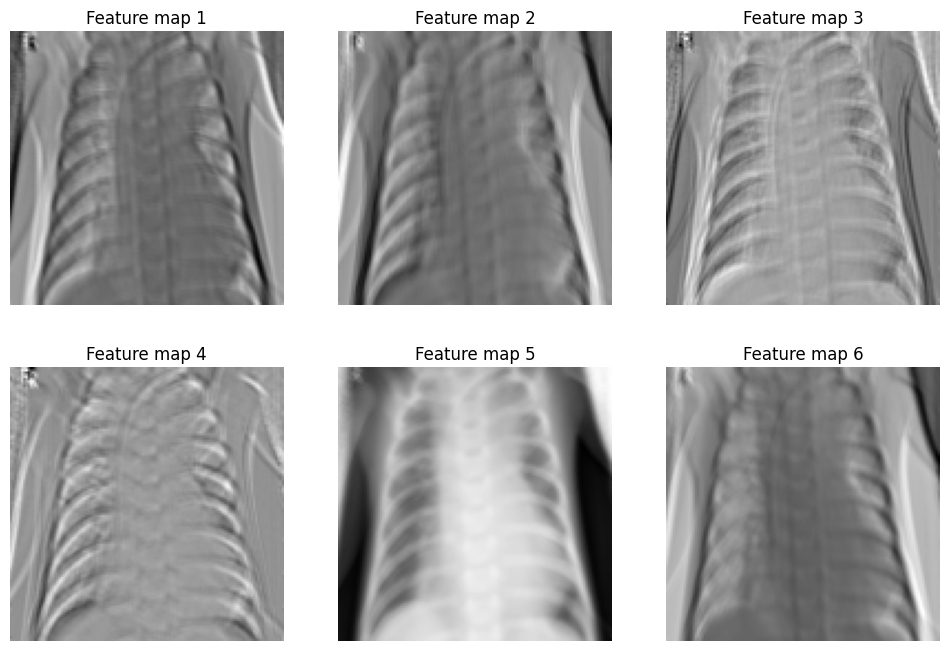

In [16]:
visualize_features(model, "/kaggle/input/pediatric-pneumonia-chest-xray/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/person109_bacteria_527.jpeg")
